# Anomaly and Outlier Detection

# Removed stuff 
<span style="color: red;">_url_x</span> deleted because it is the same as 'cyclist'in the merged dataset\
<span style="color: red;">name_x</span> deleted because it is the name of the cyclist, but we use 'cyclist' as identifier\
birth_year\
weight\
height\
nationality\
_url_y\
name_y\
name\
points\
<span style="color: red;">uci_points </span> deleted because many values are missing and we use points\
length\
<span style="color: red;">climb_total </span> deleted because many values are missing and we use profile because highly correlated\
profile\
startlist_quality\
<span style="color: red;">average_temperature </span> deleted because many values are missing \
date\
position\
cyclist\
cyclist_age\
is_tarmac\
<span style="color: red;">is_cobbled </span> deleted because all false \
<span style="color: red;">is_gravel </span> deleted because all false \
<span style="color: red;">cyclist_team </span> deleted because many values are missing \
delta



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import gzip

In [2]:
with gzip.open('clean_merged_df.pkl', 'r') as file:
    clean_merged_dataset = pickle.load(file)

In [3]:
clean_merged_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 474817 entries, 0 to 475398
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   _url_x             474817 non-null  object
 1   name_x             474817 non-null  object
 2   birth_year         474817 non-null  int64 
 3   weight             474817 non-null  int64 
 4   height             474817 non-null  int64 
 5   nationality        474817 non-null  object
 6   race_id            474817 non-null  object
 7   name_y             474817 non-null  object
 8   points             474817 non-null  int64 
 9   length             474817 non-null  int64 
 10  profile            474817 non-null  int64 
 11  startlist_quality  474817 non-null  int64 
 12  date               474817 non-null  object
 13  position           474817 non-null  int64 
 14  cyclist            474817 non-null  object
 15  cyclist_age        474817 non-null  int64 
 16  is_tarmac          474817

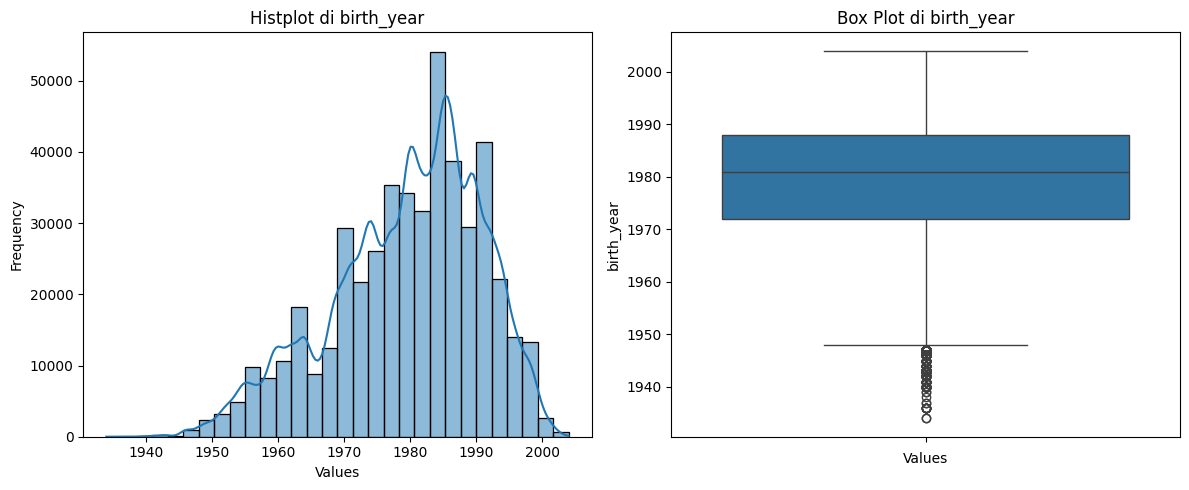

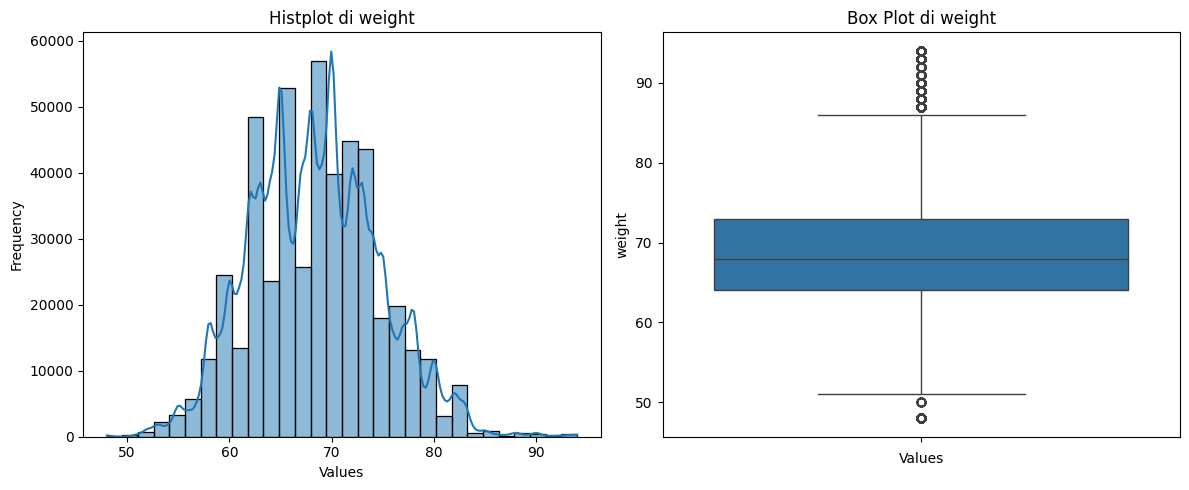

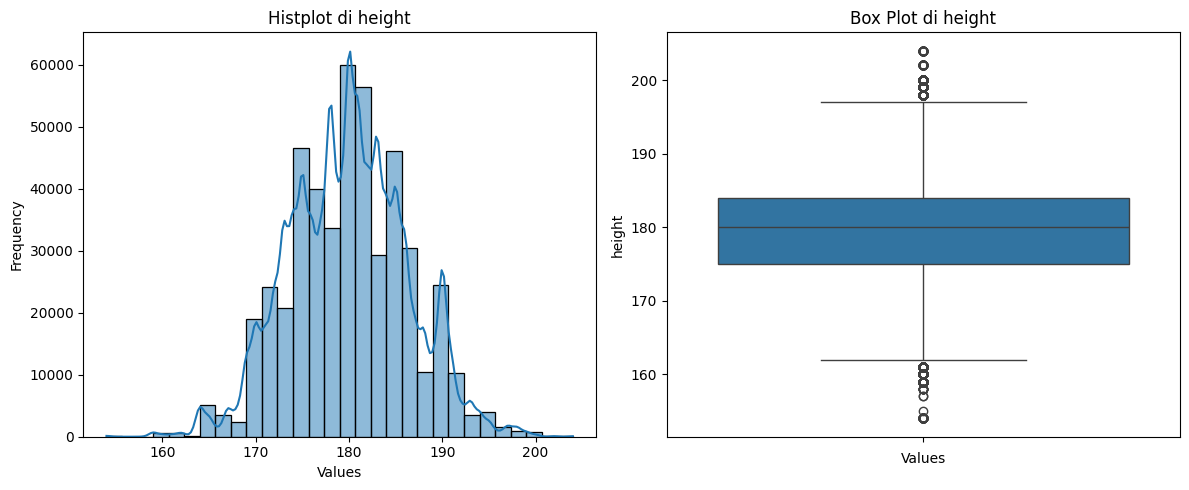

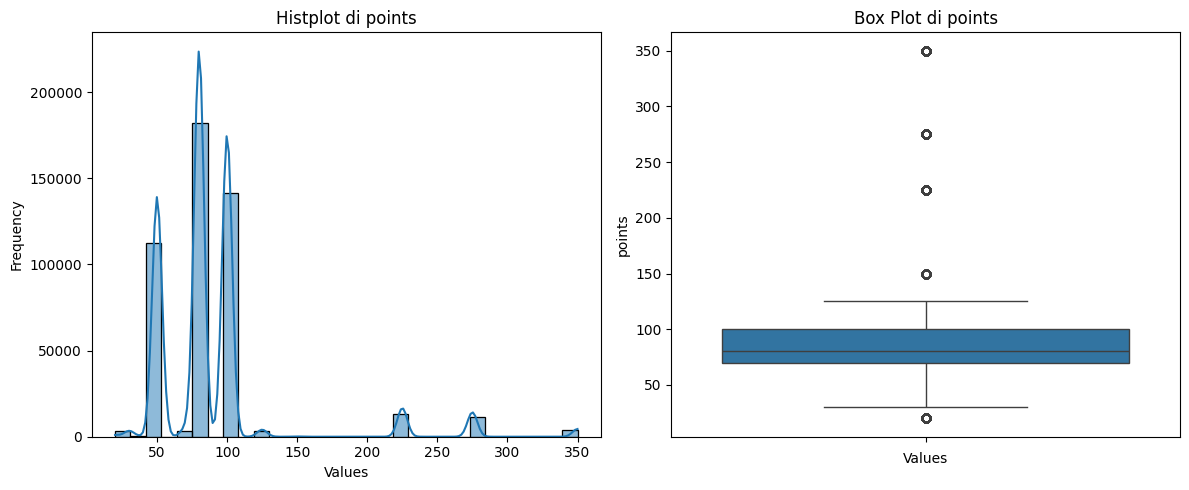

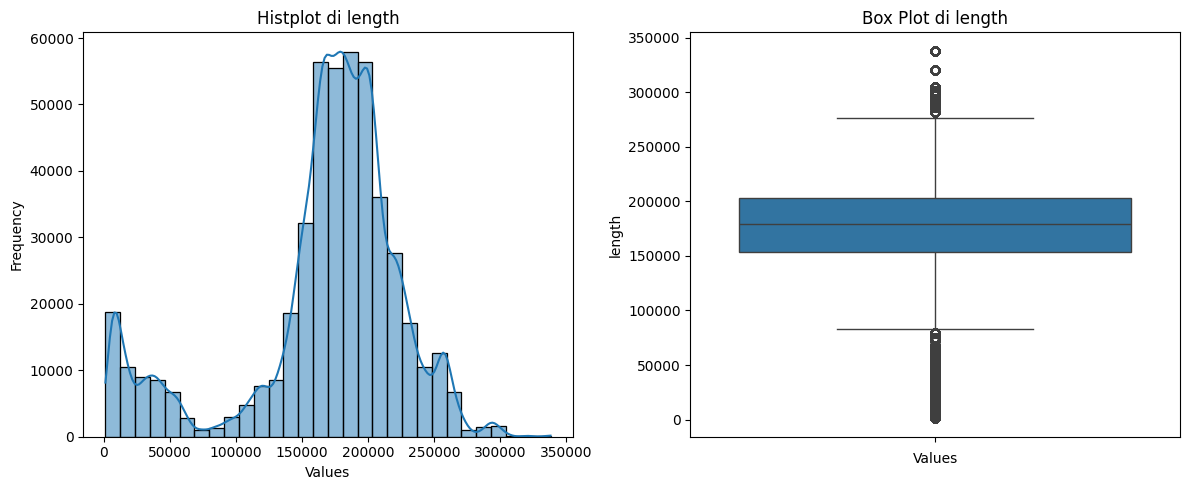

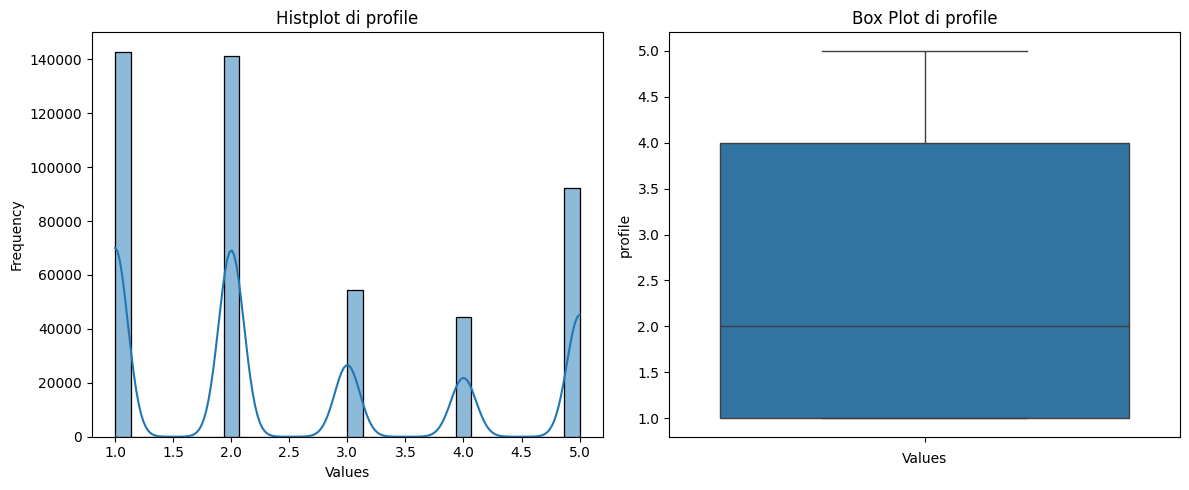

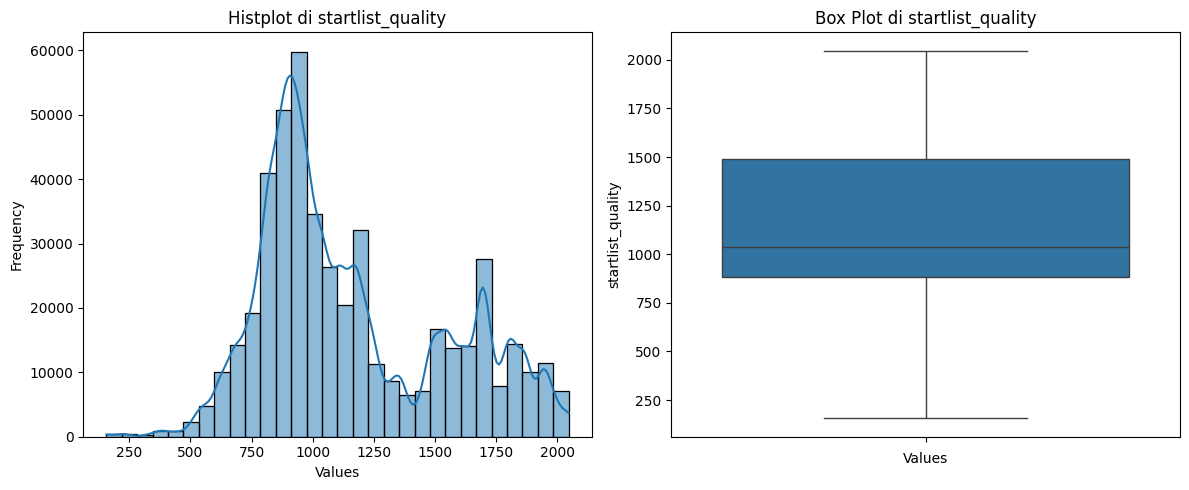

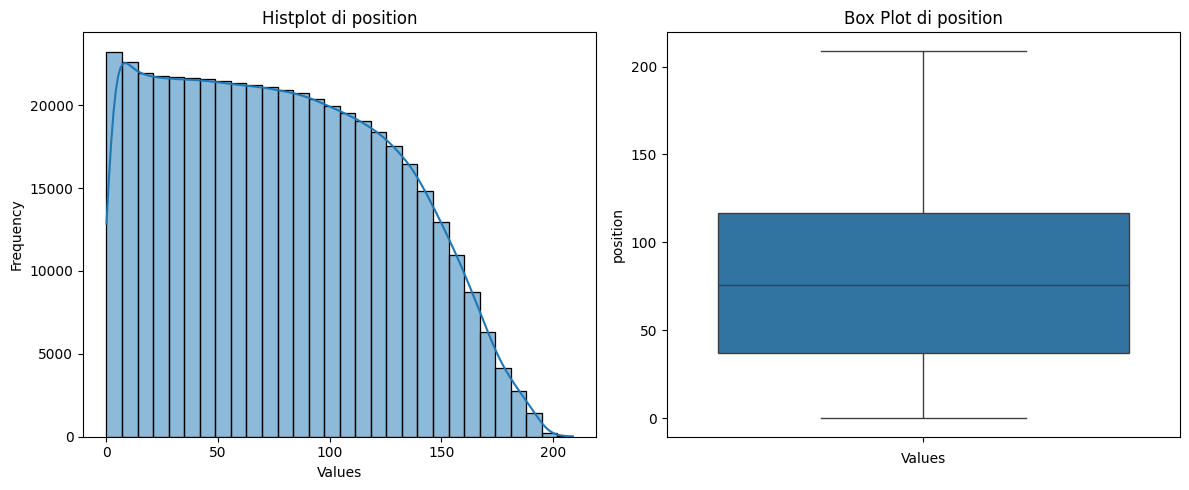

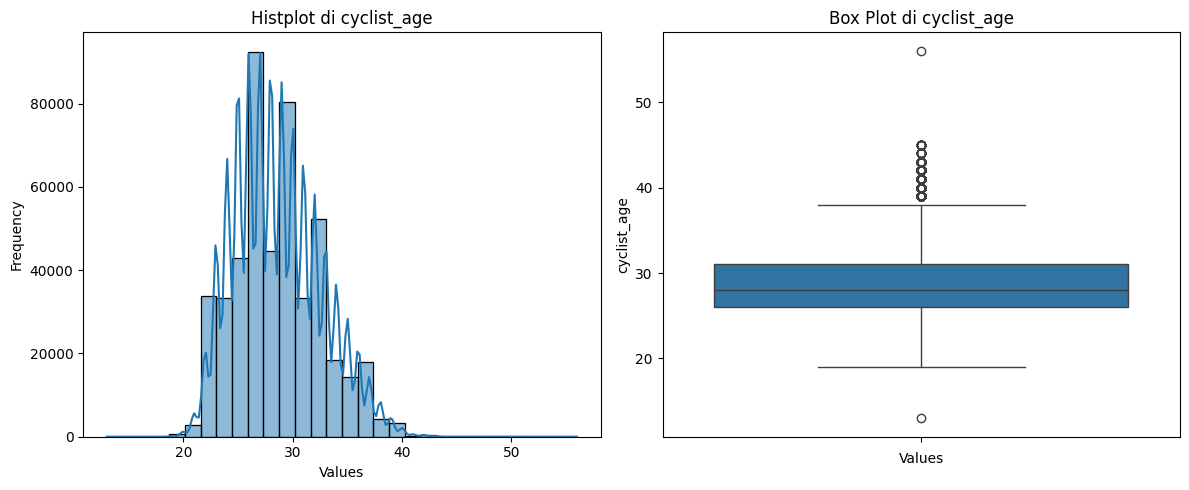

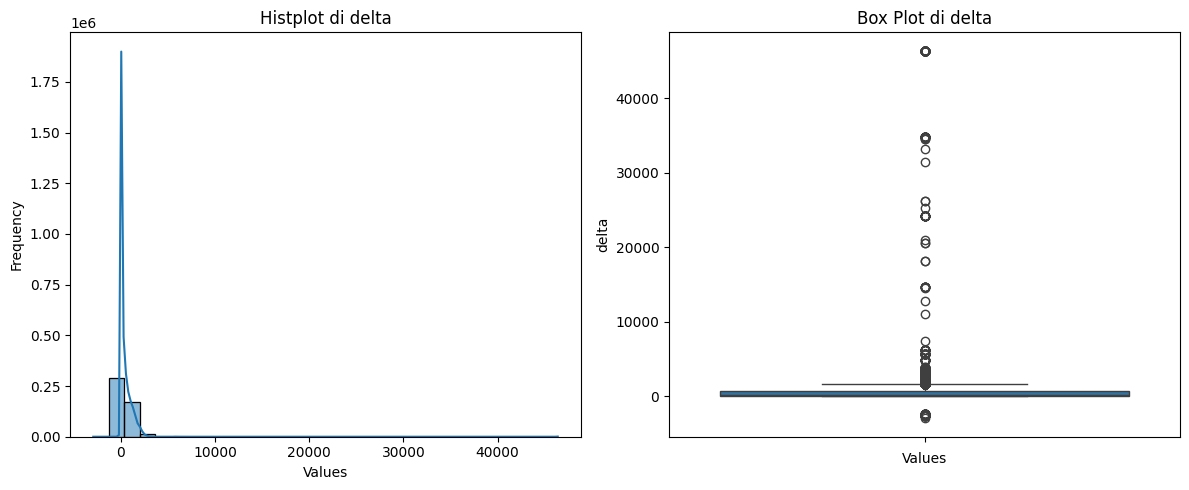

In [ ]:
columns_to_select  = clean_merged_dataset.select_dtypes(include=['number']).columns

# Create histplot and box plot of the same feature
for col in columns_to_select:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Crea una figura con due subplot fianco a fianco
    
    # Histplot
    sns.histplot(clean_merged_dataset[col], bins=30, kde=True, ax=axes[0], edgecolor='black')
    axes[0].set_title(f'Histplot di {col}')
    axes[0].set_xlabel('Values')
    axes[0].set_ylabel('Frequency')
    
    # Box plot
    sns.boxplot(y=clean_merged_dataset[col], ax=axes[1])
    axes[1].set_title(f'Box Plot di {col}')
    axes[1].set_xlabel('Values')
    
    # Show graph
    plt.tight_layout()
    plt.show()


- Print some high startlist_quality races

In [ ]:
# get some races of startlist_quality > x
high_startlist = clean_merged_dataset[clean_merged_dataset['startlist_quality'] >= 1400]

for name in high_startlist['name_y'].unique():
    print(name)

Tour de France
World Championships - Road Race
World Championships ME - Road Race
Milano-Sanremo
Clasica Ciclista San Sebastian


- Print some high points races

In [ ]:
# get some races of points > x
high_points = clean_merged_dataset[clean_merged_dataset['points'] >= 200]

for name in high_points['name_y'].unique():
    print(name)

Ronde van Vlaanderen / Tour des Flandres
World Championships - Road Race
Clasica Ciclista San Sebastian
Amstel Gold Race
La Flèche Wallonne
Donostia San Sebastian Klasikoa
Milano-Sanremo
Strade Bianche
Omloop Het Nieuwsblad ME
Liège-Bastogne-Liège
World Championships ME - Road Race
Grand Prix Cycliste de Québec
Paris-Roubaix
Dwars door Vlaanderen - A travers la Flandre ME
Ronde van Vlaanderen - Tour des Flandres ME
E3 Saxo Bank Classic
Grand Prix Cycliste de Montréal
E3 BinckBank Classic
E3 Saxo Classic
Liège - Bastogne - Liège
Il Lombardia
Paris - Roubaix
Ronde van Vlaanderen / Tour des Flandres ME
Grand Prix Cycliste de Quebec
Giro di Lombardia
Clásica Ciclista San Sebastián
Record Bank E3 Harelbeke
Dwars door Vlaanderen / A travers la Flandre ME
Clásica Ciclista San Sebastian
E3 Harelbeke
E3 Prijs Vlaanderen
E3 Prijs Vlaanderen - Harelbeke


Observations:
- points has some 'extreme' categories of races, for example the score of 350 is given to the world championship, it is a very important race and thus a difficult one, so its value is justified.
- startlist_quality seems to be split into 2 categories (bimodal distribution). The distribution on the right hand side of the histogram is related to high prestige races such as Tour de France and World Championship.

- Print some low length races starting from lowest length

In [ ]:
low_length = clean_merged_dataset[clean_merged_dataset['length'] <= 50000]
low_length = low_length.sort_values(by='length',ascending=True)

for name in low_length['race_id'].unique():
    print(name)

giro-d-italia/2005/prologue
tour-de-romandie/2008/prologue
paris-nice/2013/prologue
tour-de-romandie/2012/prologue
tour-de-romandie/2011/prologue
volta-a-catalunya/2009/stage-1
volta-a-catalunya/2008/prologue
tour-de-romandie/2019/prologue
tour-de-romandie/2016/prologue
dauphine/2016/prologue
paris-nice/2005/prologue
tour-de-romandie/2018/prologue
tour-de-romandie/2021/prologue
tour-de-france/1986/prologue
giro-d-italia/2000/prologue
paris-nice/2007/prologue
tour-de-romandie/2017/prologue
vuelta-a-espana/2009/stage-1
paris-nice/2006/prologue
tour-de-france/1983/prologue
tour-de-france/1979/prologue
tour-de-suisse/2015/prologue
tour-de-romandie/2022/prologue
tour-de-france/1978/prologue
tour-de-france/1984/prologue
tour-de-france/1991/prologue
dauphine/2011/prologue
tirreno-adriatico/2015/stage-1
tour-de-romandie/2014/prologue
vuelta-a-espana/1985/prologue
dauphine/2012/prologue
vuelta-a-espana/1986/prologue
tour-de-france/1981/prologue
tour-de-suisse/2017/stage-1
vuelta-a-espana/1999/p

Observations:
- After searching online for specific low length races, we found out that they are part of a 'individual time trial' or 'prologue'. According to wikipedia individual time trials are often used as stages in stage races such as the Grand Tours; these vary from short prologue time trials over no more than eight kilometres (designed to create an attacking racing style earlier in the race) to longer distance events over flat or rolling courses, to timed ascents of mountain roads (mountain time trial). [Individual_time_trial](https://en.wikipedia.org/wiki/Individual_time_trial)\
This explain the sort of bimodal distribution we see in the histogram.

We checked the age of the cyclist and:
- there is only one cyclist aged 13 in a race: 'plamen-stanev' and he appear in this race only, so it can be removed, a lower threshold could be 19 years old.
- there is only one cyclist aged 56 in a race: 'jose-azevedo-goncalves' and he appeared only in another race so it can be removed. he is also born in 1940. a higher threshold could be 45 years old.

In [8]:
filtered_clean_dataset = clean_merged_dataset[(clean_merged_dataset['cyclist_age'] >= 19) & (clean_merged_dataset['cyclist_age'] <= 45)] 

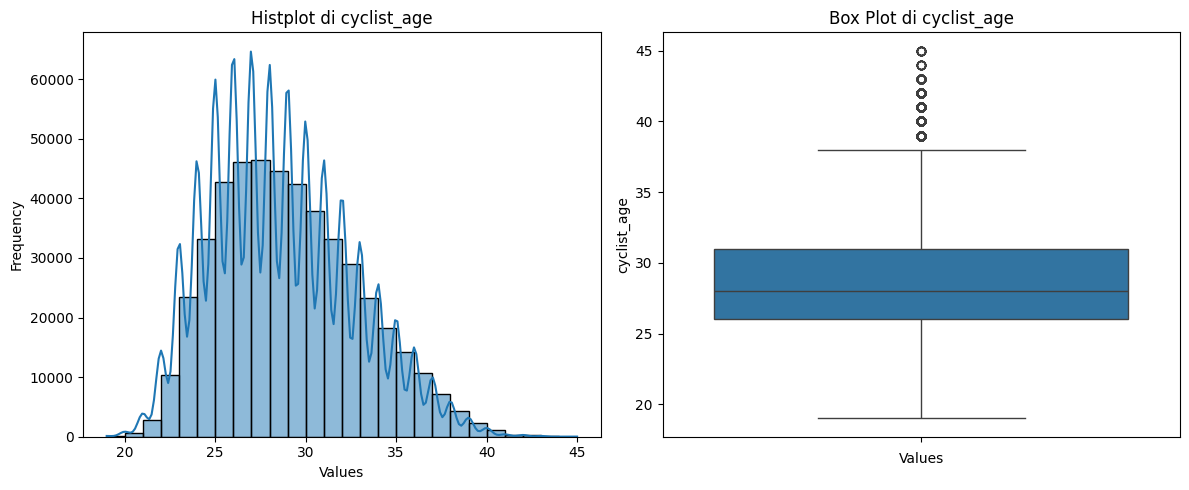

In [ ]:
columns_to_select  = ['cyclist_age']

# Same as before, histplot and boxplot of same feature
for col in columns_to_select:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histplot
    sns.histplot(filtered_clean_dataset[col], bins=26, kde=True, ax=axes[0], edgecolor='black')
    axes[0].set_title(f'Histplot di {col}')
    axes[0].set_xlabel('Values')
    axes[0].set_ylabel('Frequency')
    
    # Box plot
    sns.boxplot(y=filtered_clean_dataset[col], ax=axes[1])
    axes[1].set_title(f'Box Plot di {col}')
    axes[1].set_xlabel('Values')
    
    plt.tight_layout()
    plt.show()


In [ ]:
import re

# check if the date of the url corresponds to the date of 'date' before creating new features
# Es: 
# url: vuelta-a-espana/2017/stage-20 
# date: 2017-09-09 03:31:33
# In this case 2017 is the same so there are no errors, i can change the date to 2017 safely

different = []
pattern = r'(?P<anno>\d{4})'

for index,(url,date) in enumerate(zip(filtered_clean_dataset['race_id'],filtered_clean_dataset['date'])):
    first = re.search(pattern, url).group()
    second = re.search(r'\d+', date).group()
    if(first != second):
        different.append(index)

if(len(different) == 0):
    print('No different values')


No different values


In [ ]:
# Convert 'date' in a datetime type
filtered_clean_dataset['date'] = pd.to_datetime(filtered_clean_dataset.loc[:,'date'])

# Create 'year' column  taking year only
filtered_clean_dataset.loc[:,'year'] = filtered_clean_dataset['date'].dt.year

# Create 'date' column with only month and day
filtered_clean_dataset.loc[:,'month_day'] = filtered_clean_dataset['date'].dt.strftime('%m-%d')

# Show the dataset
filtered_clean_dataset.head()

C:\Users\Fede\AppData\Local\Temp\ipykernel_3608\3151211743.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_clean_dataset['date'] = pd.to_datetime(filtered_clean_dataset.loc[:,'date'])
C:\Users\Fede\AppData\Local\Temp\ipykernel_3608\3151211743.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_clean_dataset.loc[:,'year'] = filtered_clean_dataset['date'].dt.year
C:\Users\Fede\AppData\Local\Temp\ipykernel_3608\3151211743.py:8: SettingWithCopyWarning: 
A value is trying to be set on a cop

,_url_x,name_x,birth_year,weight,height,nationality,race_id,name_y,points,length,profile,startlist_quality,date,position,cyclist,cyclist_age,is_tarmac,delta,year,month_day
0,bruno-surra,Bruno Surra,1964,72,187,Italy,vuelta-a-espana/1989/stage-1,Vuelta a España,80,20100,1,803,1989-04-24 00:25:33,110,bruno-surra,25,True,15,1989,04-24
1,gerard-rue,Gérard Rué,1965,74,182,France,tour-de-france/1997/stage-2,Tour de France,100,262000,1,1994,1997-07-07 06:27:47,132,gerard-rue,32,True,0,1997,07-07
2,gerard-rue,Gérard Rué,1965,74,182,France,tour-de-france/1990/stage-1,Tour de France,100,138500,1,1959,1990-07-01 03:29:36,66,gerard-rue,25,True,635,1990,07-01
3,gerard-rue,Gérard Rué,1965,74,182,France,tour-de-france/1992/stage-7,Tour de France,100,196500,1,2047,1992-07-11 04:22:52,35,gerard-rue,27,True,65,1992,07-11
4,gerard-rue,Gérard Rué,1965,74,182,France,tour-de-france/1990/stage-9,Tour de France,100,196000,2,1959,1990-07-09 04:46:44,41,gerard-rue,25,True,37,1990,07-09


In [ ]:
filtered_clean_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 474815 entries, 0 to 475398
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   _url_x             474815 non-null  object        
 1   name_x             474815 non-null  object        
 2   birth_year         474815 non-null  int64         
 3   weight             474815 non-null  int64         
 4   height             474815 non-null  int64         
 5   nationality        474815 non-null  object        
 6   race_id            474815 non-null  object        
 7   name_y             474815 non-null  object        
 8   points             474815 non-null  int64         
 9   length             474815 non-null  int64         
 10  profile            474815 non-null  int64         
 11  startlist_quality  474815 non-null  int64         
 12  date               474815 non-null  datetime64[ns]
 13  position           474815 non-null  int64        

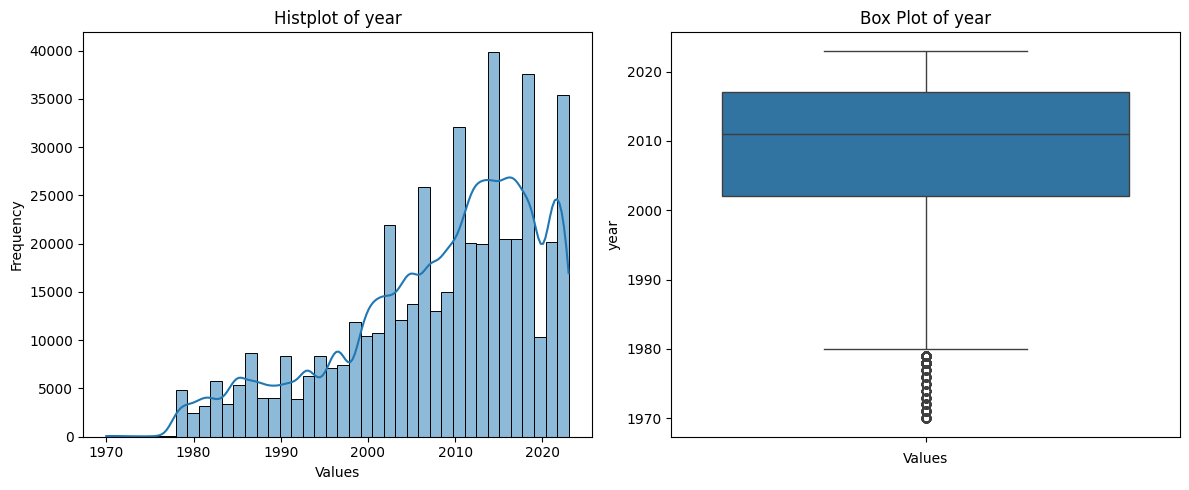

In [ ]:
columns_to_select  = ['year']

for col in columns_to_select:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histplot
    sns.histplot(filtered_clean_dataset[col], bins=40, kde=True, ax=axes[0], edgecolor='black')
    axes[0].set_title(f'Histplot of {col}')
    axes[0].set_xlabel('Values')
    axes[0].set_ylabel('Frequency')
    
    # Box plot
    sns.boxplot(y=filtered_clean_dataset[col], ax=axes[1])
    axes[1].set_title(f'Box Plot of {col}')
    axes[1].set_xlabel('Values')
    
    plt.tight_layout()
    plt.show()


- Show the amount of races for each year

In [ ]:
year_counts = filtered_clean_dataset['year'].value_counts()
print(year_counts)

year
2017    20527
2016    20525
2014    20319
2021    20215
2012    20039
2013    19953
2015    19582
2022    19484
2019    19185
2018    18387
2011    17126
2023    15922
2009    15030
2010    14929
2007    14469
2005    13721
2008    13064
2004    12102
2006    11410
2002    11239
2001    10777
2003    10683
2000    10476
2020    10289
1999     8100
1997     7402
1996     7131
1993     6259
1985     5360
1987     4553
1991     4387
1994     4258
1986     4162
1995     4117
1988     4009
1989     3970
1992     3954
1990     3942
1998     3764
1984     3416
1982     3196
1981     3160
1979     2621
1983     2546
1980     2466
1978     2250
1970       69
1971       57
1976       53
1972       42
1973       39
1977       33
1975       28
1974       18
Name: count, dtype: int64


# Very few races for 1970-1977, delete them

In [ ]:
filtered_clean_dataset = filtered_clean_dataset[(filtered_clean_dataset['year'] > 1977)] 

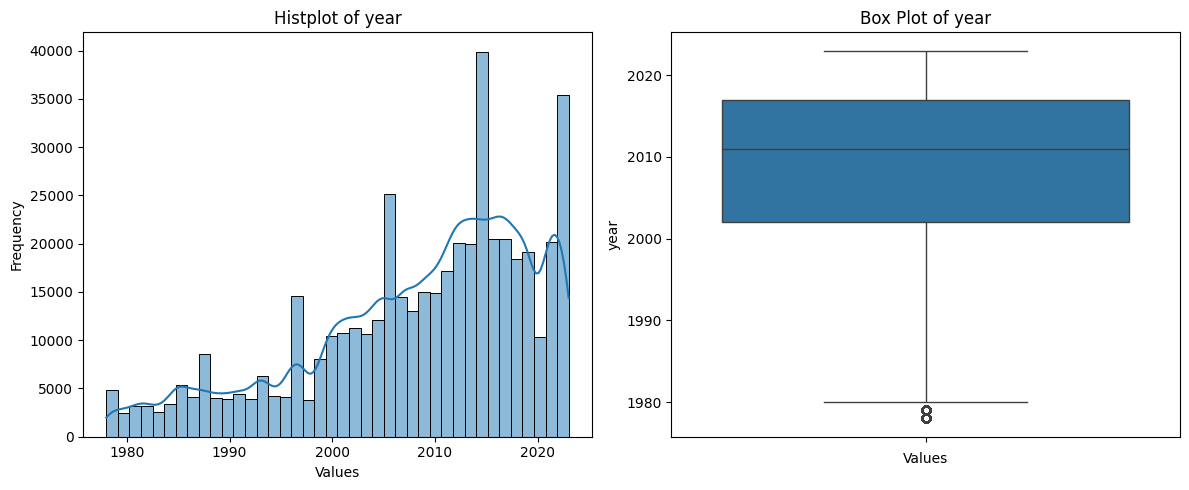

In [ ]:
columns_to_select  = ['year']

# Crea un grafico per ogni colonna
for col in columns_to_select:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Crea una figura con due subplot fianco a fianco
    
    # Histplot
    sns.histplot(filtered_clean_dataset[col], bins=40, kde=True, ax=axes[0], edgecolor='black')
    axes[0].set_title(f'Histplot of {col}')
    axes[0].set_xlabel('Values')
    axes[0].set_ylabel('Frequency')
    
    # Box plot
    sns.boxplot(y=filtered_clean_dataset[col], ax=axes[1])
    axes[1].set_title(f'Box Plot of {col}')
    axes[1].set_xlabel('Values')
    
    # Mostra il grafico
    plt.tight_layout()
    plt.show()


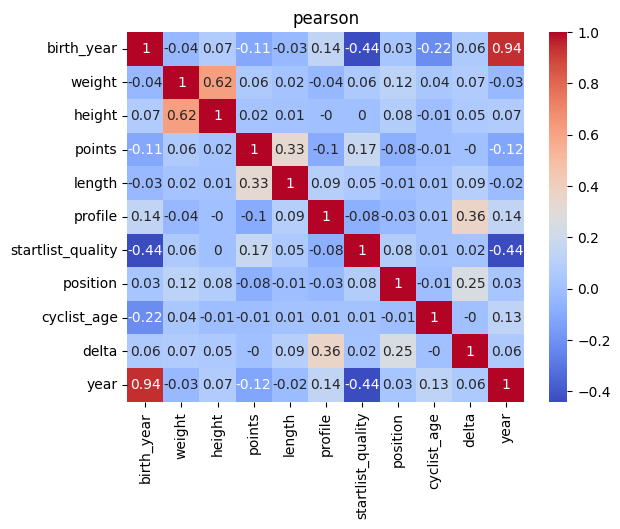

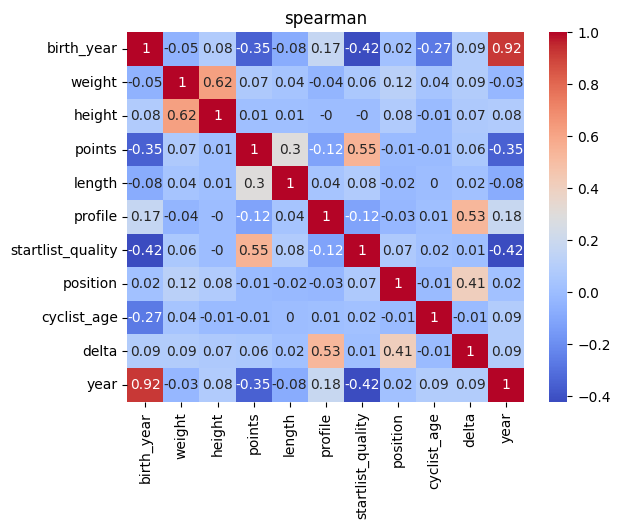

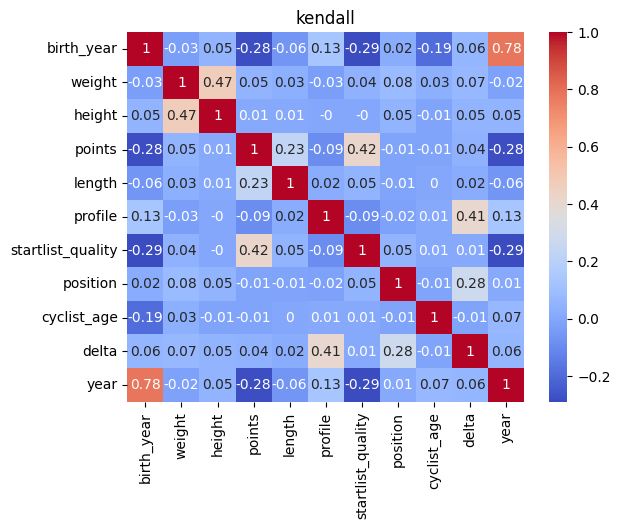

In [ ]:
clean_merged_dataset_numerical = filtered_clean_dataset.select_dtypes(include=[float, int])

# pearson correlation
plt.figure()
clean_merged_dataset_correlation = clean_merged_dataset_numerical.corr('pearson')
plt.title('pearson')
sns.heatmap(clean_merged_dataset_correlation.round(2),annot=True, cmap='coolwarm')
plt.show()

# spearman correlation
plt.figure()
plt.title('spearman')
clean_merged_dataset_correlation = clean_merged_dataset_numerical.corr('spearman')
sns.heatmap(clean_merged_dataset_correlation.round(2),annot=True, cmap='coolwarm')
plt.show()

# kendall correlation
plt.figure()
plt.title('kendall')
clean_merged_dataset_correlation = clean_merged_dataset_numerical.corr('kendall')
sns.heatmap(clean_merged_dataset_correlation.round(2),annot=True, cmap='coolwarm')
plt.show()

# year and birth_year highly correlated due to the fact that the average age for each race is in a very small interval

<Axes: xlabel='year', ylabel='birth_year'>

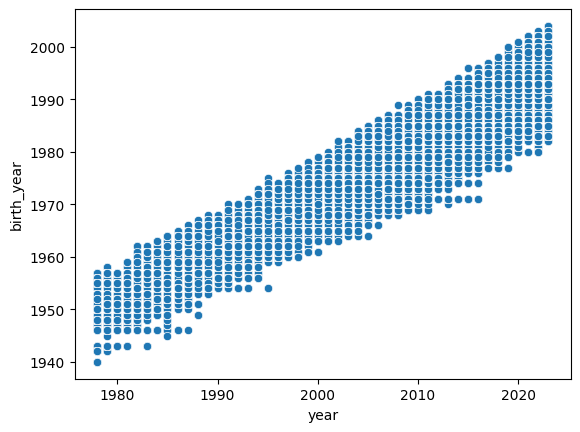

In [ ]:
sns.scatterplot(filtered_clean_dataset,
                x='year',
                y='birth_year')

In [ ]:
import pickle
import gzip

save = True

if save:
    with gzip.open('filtered_clean_merged_df.pkl', 'wb') as file:
        pickle.dump(filtered_clean_dataset, file)